In [1]:
import os
import sam3
import torch

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

# use all available GPUs on the machine
gpus_to_use = range(1)

from sam3.model_builder import build_sam3_video_predictor

predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use, checkpoint_path="/localhome/local-vennw/code/sam3/sam3.pt")

import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

# font size for axes titles
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id):
    # we will just propagate from frame 0 to the end of the video
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

/localhome/local-vennw/code/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO 2026-03-02 04:00:32,978 1663690 sam3_video_predictor.py: 300: using the following GPU IDs: [0]
INFO 2026-03-02 04:00:33,118 1663690 sam3_video_predictor.py: 316: 


	*** START loading model on all ranks ***


INFO 2026-03-02 04:00:33,120 1663690 sam3_video_predictor.py: 318: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-03-02 04:00:38,043 1663690 sam3_video_base.py: 125: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-03-02 04:00:40,438 1663690 sam3_video_predictor.py: 320: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-03-02 04:00:40,439 1663690 sam3_video_predictor.py: 331: 


	*** DONE

In [17]:
# "video_path" needs to be either a JPEG folder or a MP4 video file
task = "sztask6_020902100211021202260227_merged"
camera = "observation.images.head_right_camera_color_optical_frame"
episode = "episode_000900"
video_path = f"/localhome/local-vennw/code/{task}/videos/chunk-000/{camera}/{episode}.mp4"


# load "video_frames_for_vis" for visualization purposes (they are not used by the model)
if isinstance(video_path, str) and video_path.endswith(".mp4"):
    cap = cv2.VideoCapture(video_path)
    video_frames_for_vis = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        video_frames_for_vis.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
else:
    video_frames_for_vis = glob.glob(os.path.join(video_path, "*.jpg"))
    try:
        # integer sort instead of string sort (so that e.g. "2.jpg" is before "11.jpg")
        video_frames_for_vis.sort(
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
    except ValueError:
        # fallback to lexicographic sort if the format is not "<frame_index>.jpg"
        print(
            f'frame names are not in "<frame_index>.jpg" format: {video_frames_for_vis[:5]=}, '
            f"falling back to lexicographic sort."
        )
        video_frames_for_vis.sort()

In [18]:
idx = 0
camera_name = camera.split(".")[2]
cv2.imwrite(f"frame{idx}_{camera_name}_ar.png", cv2.cvtColor(video_frames_for_vis[idx], cv2.COLOR_RGB2BGR))

True

### Opening an inference session on this video

SAM 3 requires stateful inference for interactive video segmentation, so we need to initialize an **inference session** on this video.

During initialization, it loads all the video frames and stores their pixels in the session state.

In [7]:
response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=video_path,
    )
)
session_id = response["session_id"]

frame loading (OpenCV) [rank=0]: 100%|██████████| 483/483 [00:01<00:00, 482.47it/s]


### Video promptable concept segmentation with text

Using SAM 3 you can describe objects using natural language, and the model will automatically detect and track all instances of that object throughout the video.

In the example below, we add a text prompt on frame 0 and propagation throughout the video. Here we use the text prompt "person" to detect all people in the video. SAM 3 will automatically identify multiple person instances and assign each a unique object ID.

Note that the first call might be slower due to setting up buffers. **You can rerun all the cells below when measuring speed.**

Adding 1 prompts in the same session: ['metal items']


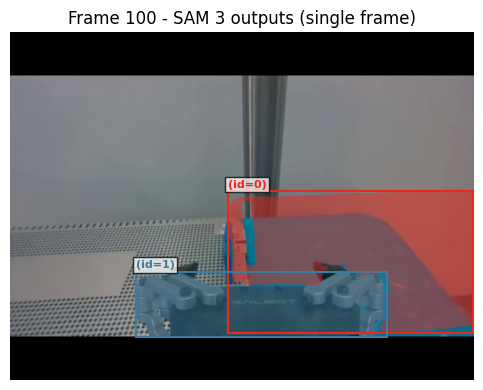

Adding 1 prompts in the same session: ['blue items']


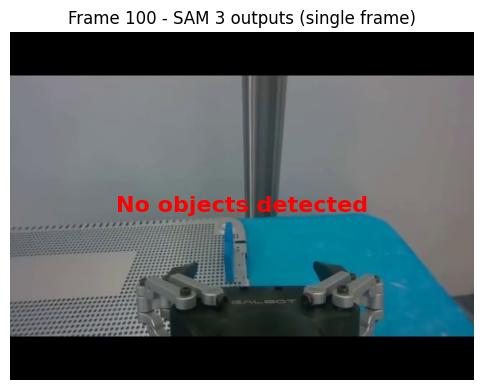

In [14]:
for prompt in ["metal items", "blue items"]:
    # "blue table", "metal items", "red item", "robotic arm(s)", "blue item"
    # "blue table", "metal items", "robotic arm(s)", "tools"
    prompts_list = [prompt]
    frame_idx = 100

    # note: in case you already ran one text prompt and now want to switch to another text prompt
    # it's required to reset the session first (otherwise the results would be wrong)
    _ = predictor.handle_request(
        request=dict(
            type="reset_session",
            session_id=session_id,
        )
    )

    print(f"Adding {len(prompts_list)} prompts in the same session: {prompts_list}")

    # reset once, then add all prompts to the same session
    _ = predictor.handle_request(
        request=dict(type="reset_session", session_id=session_id)
    )

    out = None
    for p in prompts_list:
        resp = predictor.handle_request(dict(
            type="add_prompt",
            session_id=session_id,
            frame_index=frame_idx,
            text=p,
        ))
        out = resp["outputs"]  # 当前帧结果（不需要 propagate）

    # 只可视化当前帧
    plt.close("all")
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
        titles=["SAM 3 outputs (single frame)"],
        figsize=(6, 4),
    )

In [ ]:
# propagate once
final_formatted_outputs = propagate_in_video(predictor, session_id)

In [ ]:
plt.close("all")
for i in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300]:
    if i not in final_formatted_outputs:
        continue
    out_sample = final_formatted_outputs[i]
    visualize_formatted_frame_output(
        i,
        video_frames_for_vis,
        outputs_list=[prepare_masks_for_visualization({i: out_sample})],
        titles=[f"SAM 3 outputs (frame {i})"],
        figsize=(6, 4),
    )

In [ ]:
sample_img = Image.fromarray(load_frame(video_frames_for_vis[0]))

IMG_WIDTH, IMG_HEIGHT = sample_img.size

frame_idx = 0


def add_objects_with_points(predictor, session_id, frame_idx, objects, img_width, img_height):
    outputs = []
    points_list = []
    labels_list = []

    for obj in objects:
        obj_id = obj["obj_id"]
        points_abs = np.array(obj["points_abs"], dtype=np.float32)
        labels = np.array(obj["labels"], dtype=np.int32)

        points_tensor = torch.tensor(
            abs_to_rel_coords(points_abs, img_width, img_height, coord_type="point"),
            dtype=torch.float32,
        )
        labels_tensor = torch.tensor(labels, dtype=torch.int32)

        response = predictor.handle_request(
            request=dict(
                type="add_prompt",
                session_id=session_id,
                frame_index=frame_idx,
                points=points_tensor,
                point_labels=labels_tensor,
                obj_id=obj_id,
            )
        )
        outputs.append(response["outputs"])
        points_list.append(points_abs)
        labels_list.append(labels)

    return outputs, points_list, labels_list


objects = [
    {"obj_id": 2, "points_abs": [[5.7, 410.5], [121.8, 254.1], [105.1, 334.9], [48, 381]], "labels": [1, 1, 1, 1]},
]

outs, points_list, labels_list = add_objects_with_points(
    predictor,
    session_id,
    frame_idx,
    objects,
    IMG_WIDTH,
    IMG_HEIGHT,
)

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out}) for out in outs],
    titles=[f"obj {i}" for i in range(len(outs))],
    figsize=(6, 4),
    points_list=points_list,
    points_labels_list=labels_list,
)

In [ ]:
# propagate once
final_formatted_outputs = propagate_in_video(predictor, session_id)

In [ ]:
plt.close("all")
for i in [0, 25, 50, 100, 150, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300]:
    if i not in final_formatted_outputs:
        continue
    out_sample = final_formatted_outputs[i]
    visualize_formatted_frame_output(
        i,
        video_frames_for_vis,
        outputs_list=[prepare_masks_for_visualization({i: out_sample})],
        titles=[f"SAM 3 outputs (frame {i})"],
        figsize=(6, 4),
    )

In [ ]:
# let's add back the dancer via point prompts.
# we will use a single positive click to add the dancer back.

frame_idx = 50
obj_id = 3
points_abs = np.array(
    [
        [520.6, 404.6], [568, 354]
    ]
)
# positive clicks have label 1, while negative clicks have label 0
labels = np.array([1, 1])

In [ ]:
# convert points and labels to tensors; also convert to relative coordinates
points_tensor = torch.tensor(
    abs_to_rel_coords(points_abs, IMG_WIDTH, IMG_HEIGHT, coord_type="point"),
    dtype=torch.float32,
)
points_labels_tensor = torch.tensor(labels, dtype=torch.int32)

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        points=points_tensor,
        point_labels=points_labels_tensor,
        obj_id=obj_id,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
    points_list=[points_abs],
    points_labels_list=[labels],
)

In [ ]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

### Refining an existing object with point prompts

We can also refine the segmentation mask of an existing object through point prompts.

Assuming that we've changed our mind (again) -- for Object ID 2 (the dancer in the front whom we just added back in the step above), now we only want to segment her T-shirt instead of her whole body. We can adjust the segmentation mask with a few more positive and negative clicks.

In [ ]:
# For the dancer in the front, suppose now we only want to segment her T-shirt instead of her whole body
# we will use 2 positive clicks and 2 negative clicks to select her shirt.

frame_idx = 0
obj_id = 3
points_abs = np.array(
    [
        [307, 220], [318, 280], [289.6, 274.8], [345.6, 273.6]
    ]
)
# positive clicks have label 1, while negative clicks have label 0
labels = np.array([1, 1, 1, 1])

In [ ]:
# convert points and labels to tensors; also convert to relative coordinates
points_tensor = torch.tensor(
    abs_to_rel_coords(points_abs, IMG_WIDTH, IMG_HEIGHT, coord_type="point"),
    dtype=torch.float32,
)
points_labels_tensor = torch.tensor(labels, dtype=torch.int32)

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        points=points_tensor,
        point_labels=points_labels_tensor,
        obj_id=obj_id,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
    points_list=[points_abs],
    points_labels_list=[labels],
)

In [ ]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

### Close session

Each session is tied to a single video. We can close the session after inference to free up its resources.

(Then, you may start a new session on another video.)

In [ ]:
# finally, close the inference session to free its GPU resources
# (you may start a new session on another video)
_ = predictor.handle_request(
    request=dict(
        type="close_session",
        session_id=session_id,
    )
)

### Clean-up

After all inference is done, we can shutdown the predictor to free up the multi-GPU process group.

In [ ]:
# after all inference is done, we can shutdown the predictor
# to free up the multi-GPU process group
predictor.shutdown()